# Project Job Scheduling — the MRCPSP in LangGOAP

A Tier 2 tutorial that translates the Multi-mode Resource-Constrained
Project Scheduling Problem (MRCPSP) into a LangGOAP planning problem.
The original instance ports the PSPLIB multi-mode RCPSP benchmark suite.
We use a compact five-job subset
(design -> {frontend || backend} -> integrate -> deploy) with two modes
per real job so the solver runs instantly while still exercising the
key features:

- **Precedence scheduling** — the dependency DAG is extracted from
  action effect->precondition matching, the same way
  `planner/csp.py::build_dependency_graph` computes it for every
  other tutorial.
- **Mode selection** — each real job has a *fast-expensive* and a
  *slow-cheap* mode.  A\* picks whichever mode combination minimizes
  total duration (the primary objective).
- **Non-renewable resource budget** — aggregated `budget` across the
  plan turns into a `ConstraintSpec(key="budget", level="hard")`,
  flipping the pipeline into alternative-plan enumeration when the
  cheapest-by-duration plan exceeds it.
- **Makespan minimization** — per-job `timedelta` durations feed
  CP-SAT's `IntervalVar`, so makespan falls out as the longest path
  through the precedence DAG and independent jobs run in parallel.

What this tutorial **does not** cover (documented upstream in
`examples/tutorials/tutorial_examples/data/project_job_scheduling_instance.py`):
per-period renewable resource capacities, multi-project horizons,
and tardiness costs.  LangGOAP aggregates resource totals across the
whole plan but does not yet model per-time-slice capacity — exactly
the same limitation the vehicle routing tutorial calls out.

In [1]:
import logging

# The infeasibility demo further down deliberately triggers the
# CSP's "all alternatives infeasible" advisory — silence the warning.
logging.getLogger("langgoap").setLevel(logging.ERROR)

from langgoap import CSPStatus, GoapGraph
from langgoap.planner.pipeline import plan as pipeline_plan
from langgoap.state import PlanningState
from tutorial_examples.data.project_job_scheduling_instance import (
    DEFAULT_BUDGET,
    JOBS,
)
from tutorial_examples.project_job_scheduling import (
    project_job_scheduling_actions,
    project_job_scheduling_goal,
    project_job_scheduling_start,
)

print(f"Jobs: {len(JOBS)}  (default budget cap = {DEFAULT_BUDGET})")
for j in JOBS:
    preds = ', '.join(j.predecessors) if j.predecessors else '—'
    modes = ', '.join(f'{m.name}({m.duration_hours}h, ${m.budget})' for m in j.modes)
    print(f'  {j.name:<10s} preds={preds:<18s} modes=[{modes}]')

Jobs: 5  (default budget cap = 20)
  design     preds=—                  modes=[single(1h, $0)]
  frontend   preds=design             modes=[fast(3h, $10), slow(6h, $4)]
  backend    preds=design             modes=[fast(4h, $12), slow(8h, $6)]
  integrate  preds=frontend, backend  modes=[fast(2h, $8), slow(5h, $3)]
  deploy     preds=integrate          modes=[single(1h, $2)]


## 1. Action catalog — one action per (job, mode) pair

`project_job_scheduling_actions()` expands every job into one
`ActionSpec` per mode.  The resulting catalog has:

- `design_single` and `deploy_single` — trivial source and sink jobs
  with a single mode each (kept as actions so the precedence chain
  is visible in the rendered plan).
- `frontend_fast/slow`, `backend_fast/slow`, `integrate_fast/slow` —
  the two-mode real jobs.

The action cost is `duration_hours` so that A\* naturally minimizes
total work.  `resources={"duration_hours": ..., "budget": ...}`
lets the CSP phase aggregate both quantities, and
`duration=timedelta(hours=duration_hours)` feeds CP-SAT's temporal
scheduler so the makespan respects real parallelism.

In [2]:
actions = project_job_scheduling_actions()
print(f'Total actions: {len(actions)}\n')
for a in actions:
    dur = a.resources.get('duration_hours', 0.0)
    bud = a.resources.get('budget', 0.0)
    print(f'  {a.name:<22s} cost={a.cost:<3.0f} duration={dur:<3.0f}h  budget=${bud:<4.0f}')

Total actions: 8

  do_design_single       cost=1   duration=1  h  budget=$0   
  do_frontend_fast       cost=3   duration=3  h  budget=$10  
  do_frontend_slow       cost=6   duration=6  h  budget=$4   
  do_backend_fast        cost=4   duration=4  h  budget=$12  
  do_backend_slow        cost=8   duration=8  h  budget=$6   
  do_integrate_fast      cost=2   duration=2  h  budget=$8   
  do_integrate_slow      cost=5   duration=5  h  budget=$3   
  do_deploy_single       cost=1   duration=1  h  budget=$2   


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

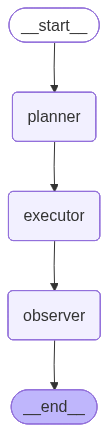

In [3]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 2. Solve the fastest schedule

The default goal asks for every job done and attaches a
`duration_hours → MINIMIZE` objective.  Because the goal has an
objective, the planner routes through the CSP phase and returns a
`HardSoftScore` together with a full per-action schedule.

A\* picks the all-fast mode combination (duration sum = 11h).
CP-SAT's `IntervalVar` scheduler then recognizes that frontend and
backend have no precedence edge between them and schedules them in
parallel after design, so the makespan drops to **8h**.

In [4]:
plan_obj = pipeline_plan(
    PlanningState.from_dict(project_job_scheduling_start()),
    project_job_scheduling_goal(),
    actions,
)

print(f'CSP status:       {plan_obj.metadata.csp.status.value}')
print(f'Duration (A*):    {plan_obj.total_cost} hours (sum of work)')
print(f'Makespan (CP-SAT): {plan_obj.metadata.csp.makespan} (wall clock)')
print()
print('Selected modes:')
for step in plan_obj.actions:
    print(f'  {step.name}')
print()
print('Schedule (parallel where precedence allows):')
for entry in plan_obj.metadata.csp.schedule:
    print(f'  {entry.action_name:<22s} {entry.start} → {entry.end}')

CSP status:       feasible
Duration (A*):    11.0 hours (sum of work)
Makespan (CP-SAT): 8:00:00 (wall clock)

Selected modes:
  do_design_single
  do_frontend_fast
  do_backend_fast
  do_integrate_fast
  do_deploy_single

Schedule (parallel where precedence allows):
  do_design_single       0:00:00 → 1:00:00
  do_frontend_fast       2:00:00 → 5:00:00
  do_backend_fast        1:00:00 → 5:00:00
  do_integrate_fast      5:00:00 → 7:00:00
  do_deploy_single       7:00:00 → 8:00:00


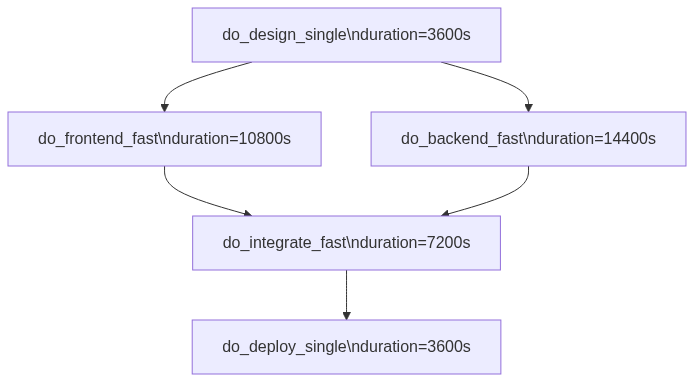

In [5]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(plan_obj))))

## 3. HardSoftScore decomposition

The pipeline translates the `duration_hours → MINIMIZE` objective
into the soft component of the score (more negative = worse).
Resource usage is reported as `level="info"` because neither
`duration_hours` nor `budget` has a `ConstraintSpec` attached yet —
they're aggregated for reporting but not enforced.

In [6]:
print(f'plan.score        = {plan_obj.score}')
print(f'score.is_feasible = {plan_obj.score.is_feasible()}')
print(f'score.value       = {plan_obj.score.value}  (scalar for logging)')
print()
print('Resource usage (info-level — no constraints yet):')
for u in plan_obj.metadata.csp.resource_usage:
    print(f'  {u.key:<16s} total={u.total:<6.1f} level={u.level}')

plan.score        = HardSoftScore(hard=0, soft=-11)
score.is_feasible = True
score.value       = -11.0  (scalar for logging)

Resource usage (info-level — no constraints yet):
  duration_hours   total=11.0   level=info
  budget           total=32.0   level=info


## 4. Hard budget → alternative-plan enumeration

The all-fast plan burns `$32` of non-renewable budget.  Adding a
hard cap of `$26` makes that plan infeasible, so the pipeline
enumerates alternatives — in this case by blacklisting the most
expensive individual action and replanning.  The resulting plan
swaps `frontend_fast` (10) for `frontend_slow` (4), cuts budget to
exactly `$26`, and lengthens duration to `14h`.

In [7]:
hard_plan = pipeline_plan(
    PlanningState.from_dict(project_job_scheduling_start()),
    project_job_scheduling_goal(max_budget=26, max_budget_level='hard'),
    actions,
)

print(f'CSP status:    {hard_plan.metadata.csp.status.value}')
print(f'Score:         {hard_plan.score}')
print(f'Duration (A*): {hard_plan.total_cost} hours')
print()
print('Selected modes:')
for step in hard_plan.actions:
    print(f'  {step.name}')
print()
print('Resource usage (budget is now a hard constraint):')
for u in hard_plan.metadata.csp.resource_usage:
    print(f'  {u.key:<16s} total={u.total:<6.1f} level={u.level}  satisfied={u.satisfied}')

CSP status:    optimal
Score:         HardSoftScore(hard=0, soft=-14)
Duration (A*): 14.0 hours

Selected modes:
  do_design_single
  do_backend_fast
  do_frontend_slow
  do_integrate_fast
  do_deploy_single

Resource usage (budget is now a hard constraint):
  budget           total=26.0   level=hard  satisfied=True
  duration_hours   total=14.0   level=info  satisfied=True


## 5. Soft budget → penalty, not rejection

A soft cap of `$20` is intentionally unreachable (even the
cheapest-by-budget all-slow plan needs `$15`, but A\* minimizes
duration and picks all-fast at `$32`).  With `level="soft"` the
pipeline keeps the primary plan and subtracts the `$12` overflow
from the soft score instead of marking it infeasible.

In [8]:
soft_plan = pipeline_plan(
    PlanningState.from_dict(project_job_scheduling_start()),
    project_job_scheduling_goal(max_budget=20, max_budget_level='soft'),
    actions,
)

print(f'CSP status: {soft_plan.metadata.csp.status.value}')
print(f'Score:      {soft_plan.score}')
print()
budget_usage = next(u for u in soft_plan.metadata.csp.resource_usage if u.key == 'budget')
print(f'budget.total = {budget_usage.total}   (cap was 20)')
print(f'budget.level = {budget_usage.level}')
print(f'budget.satisfied = {budget_usage.satisfied}')
print()
print('Soft score breakdown:')
print('  -duration_hours objective : -11')
print('  -budget overflow penalty  : -12')
print('  total                     :', soft_plan.score.soft)

CSP status: feasible
Score:      HardSoftScore(hard=0, soft=-23)

budget.total = 32.0   (cap was 20)
budget.level = soft
budget.satisfied = False

Soft score breakdown:
  -duration_hours objective : -11
  -budget overflow penalty  : -12
  total                     : -23.0


## 6. Infeasible hard cap → CSPStatus.INFEASIBLE

A budget of `$10` is below every alternative the pipeline can
reach — even the single-blacklist alternatives cannot find a
feasible combination.  The plan comes back with
`CSPStatus.INFEASIBLE` and a negative hard score tracking the
shortfall.

In [9]:
infeasible_plan = pipeline_plan(
    PlanningState.from_dict(project_job_scheduling_start()),
    project_job_scheduling_goal(max_budget=10, max_budget_level='hard'),
    actions,
)

print(f'CSP status: {infeasible_plan.metadata.csp.status.value}')
print(f'Score:      {infeasible_plan.score}')
print(f'Feasible?   {infeasible_plan.score.is_feasible()}')

CSP status: infeasible
Score:      HardSoftScore(hard=-22, soft=-11)
Feasible?   False


## 7. End-to-end execution via `GoapGraph.invoke()`

The full LangGraph loop plans, executes, and verifies the world
state.  Each action flips its `<job>_done` flag, the observer
detects that every goal condition is satisfied, and the graph
halts with `status="goal_achieved"`.

In [10]:
result = GoapGraph(actions=actions).invoke(
    goal=project_job_scheduling_goal(),
    world_state=project_job_scheduling_start(),
)

print(f'status: {result["status"]}')
print()
print('Final world state:')
for j in JOBS:
    key = f'{j.name}_done'
    print(f'  {key:<18s} {result["world_state"][key]}')

status: goal_achieved

Final world state:
  design_done        True
  frontend_done      True
  backend_done       True
  integrate_done     True
  deploy_done        True


## Summary

- **Precedence for free.** Effect→precondition chains become the
  dependency DAG CP-SAT uses to parallelize independent jobs.
- **Mode selection is A\*'s job.** Each job's multiple modes are
  separate actions; cost-minimization picks the fastest feasible
  combination.
- **Non-renewable budgets are aggregated resources.** One
  `ConstraintSpec(key="budget")` is enough to flip the pipeline
  into alternative-plan enumeration when the cheapest-by-time plan
  exceeds it.
- **Makespan comes from CP-SAT.** `IntervalVar` + precedence yields
  the true parallel makespan (8h) instead of the serial sum of
  durations (11h).
- **Soft vs hard is a one-line switch.** Replace
  `level="hard"` with `level="soft"` to record overflow as a
  penalty instead of marking the plan infeasible.

Next tutorials build on the same CP-SAT scheduler for task
assignment with weighted delay minimization and flexible job-shop
scheduling.